# 03 — Topic Modeling

Compares thematic emphasis between deuterocanonical books (Tobit, Judith, 1/2 Maccabees, Wisdom, Sirach, Baruch) and protocanonical books, per Sub-Question 2 in the project README:

> Does topic modeling reveal measurable differences in theological emphasis between deuterocanonical books and protocanonical ones?

**Source and tradition:** uses the **Catholic** processed corpus (`data/processed/catholic/`), sourced entirely from Douay-Rheims via `align_corpus.CANONICAL_SOURCES`. This is deliberate — protocanonical and deuterocanonical books need to come from the *same translation* here, otherwise any topic differences could just be an artifact of translator word choice rather than theological emphasis. The Catholic canon is the only one where all 73 books share one consistent source.

**Model choice:** starts with scikit-learn's `LatentDirichletAllocation` rather than BERTopic. BERTopic needs a heavy install (torch, sentence-transformers, umap-learn, hdbscan — multi-GB plus runtime embedding-model downloads); LDA needs nothing beyond what's already in `requirements.txt`. The proposal's Methodology section lists both as acceptable ("BERTopic/LDA"), so this gets a working comparison now — swapping in BERTopic later is a model-fitting change, not a data-pipeline change.

**Chunking:** books are split into ~150-word passages rather than modeled at the whole-book level, since a single topic per book would be too coarse to say anything about emphasis *within* a book (see the original notebook plan). Chunking is by fixed word count rather than by chapter, because `build_processed_corpus.py` deliberately strips chapter/verse markers during cleaning (see `src/build_processed_corpus.py` docstring) — the processed text is continuous prose, not chapter-tagged.

In [1]:
import json
import sys
from pathlib import Path

sys.path.append('../src')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

PROCESSED_DIR = Path('../data/processed')

manifest_path = PROCESSED_DIR / 'corpus_manifest.json'
if not manifest_path.exists():
    raise RuntimeError(
        f'{manifest_path} not found. Run `python src/build_processed_corpus.py` first '
        '(see context/NEXT_STEPS.md).'
    )

manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
canon_matrix = manifest['canon_overlap_matrix']
print(f"{len(canon_matrix)} books in the overlap matrix")

77 books in the overlap matrix


## Load the Catholic corpus and tag protocanonical vs. deuterocanonical

A Catholic-canon book is **protocanonical** if it's also in the Protestant list (`canon_matrix[book]['protestant']`), and **deuterocanonical** otherwise — this matches the 7-book deuterocanonical list in `data/metadata/canon_lists.json` (Tobit, Judith, 1 Maccabees, 2 Maccabees, Wisdom, Sirach, Baruch).

In [2]:
catholic_books = [book for book, traditions in canon_matrix.items() if traditions['catholic']]

book_records = []
for book in catholic_books:
    text_path = PROCESSED_DIR / 'catholic' / f'{book}.txt'
    category = 'protocanonical' if canon_matrix[book]['protestant'] else 'deuterocanonical'
    book_records.append({
        'book': book,
        'category': category,
        'text': text_path.read_text(encoding='utf-8'),
    })

books_df = pd.DataFrame(book_records)
print(books_df['category'].value_counts())
assert (books_df['category'] == 'deuterocanonical').sum() == 7, 'expected the 7 deuterocanonical books'

category
protocanonical      66
deuterocanonical     7
Name: count, dtype: int64


## Chunk into passages

Each book becomes a set of ~150-word passages (last partial passage dropped if under 30 words, to avoid noisy near-empty documents). Every passage inherits its book's category label.

In [3]:
CHUNK_WORDS = 150
MIN_CHUNK_WORDS = 30

passage_records = []
for _, row in books_df.iterrows():
    words = row['text'].split()
    for start in range(0, len(words), CHUNK_WORDS):
        chunk_words = words[start:start + CHUNK_WORDS]
        if len(chunk_words) < MIN_CHUNK_WORDS:
            continue
        passage_records.append({
            'book': row['book'],
            'category': row['category'],
            'text': ' '.join(chunk_words),
        })

passages_df = pd.DataFrame(passage_records)
print(f'{len(passages_df)} passages from {books_df.shape[0]} books')
print(passages_df['category'].value_counts())
print(passages_df.groupby('category')['book'].nunique().rename('unique_books'))

5953 passages from 73 books
category
protocanonical      5267
deuterocanonical     686
Name: count, dtype: int64
category
deuterocanonical     7
protocanonical      66
Name: unique_books, dtype: int64


## Fit LDA

Bag-of-words with English stopwords removed, common/rare-word filtering (`max_df`/`min_df`), and a capped vocabulary. `n_components=12` is a starting point, not a tuned value — revisit if topics look too coarse or too fragmented once you can eyeball the results below.

In [4]:
N_TOPICS = 12

vectorizer = CountVectorizer(stop_words='english', max_df=0.9, min_df=3, max_features=2000)
doc_term_matrix = vectorizer.fit_transform(passages_df['text'])
feature_names = vectorizer.get_feature_names_out()
print(f'{doc_term_matrix.shape[0]} passages x {doc_term_matrix.shape[1]} vocab terms')

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42, max_iter=20)
doc_topic_matrix = lda.fit_transform(doc_term_matrix)
passages_df['dominant_topic'] = doc_topic_matrix.argmax(axis=1)

5953 passages x 2000 vocab terms


In [5]:
def top_words(topic_weights, n=10):
    return [feature_names[i] for i in topic_weights.argsort()[-n:][::-1]]

for topic_idx, topic_weights in enumerate(lda.components_):
    print(f'Topic {topic_idx:2d}: ' + ', '.join(top_words(topic_weights)))

Topic  0: jews, came, great, men, city, went, people, king, jerusalem, day
Topic  1: said, shall, jesus, man, saying, come, say, came, god, behold
Topic  2: gold, silver, house, vessels, tabernacle, temple, brass, set, work, stones
Topic  3: shall, offer, altar, sacrifice, thereof, cubits, seven, day, lord, sin
Topic  4: sons, children, lord, israel, moses, son, thousand, people, god, aaron
Topic  5: said, king, lord, hath, god, man, father, answered, let, thee
Topic  6: land, lord, israel, people, egypt, children, men, came, went, great
Topic  7: king, son, lord, israel, juda, house, jerusalem, years, david, solomon
Topic  8: god, hath, things, man, shall, lord, unto, good, let, heart
Topic  9: david, saul, lord, said, men, went, philistines, day, man, came
Topic 10: shall, lord, hath, saith, come, earth, people, land, man, god
Topic 11: thou, thy, thee, shalt, lord, hast, shall, god, art, wilt


## Compare topic distributions: protocanonical vs. deuterocanonical

Normalized within each category (columns sum to 1), so this compares *proportions* rather than raw counts — necessary since protocanonical passages outnumber deuterocanonical ones roughly 8 to 1.

In [6]:
topic_by_category = pd.crosstab(
    passages_df['dominant_topic'], passages_df['category'], normalize='columns'
)
topic_by_category

category,deuterocanonical,protocanonical
dominant_topic,,
0,0.260933,0.031327
1,0.004373,0.101576
2,0.008746,0.019935
3,0.001458,0.027340
4,0.004373,0.059806
5,0.075802,0.103474
6,0.097668,0.077653
7,0.007289,0.066831
8,0.402332,0.160053


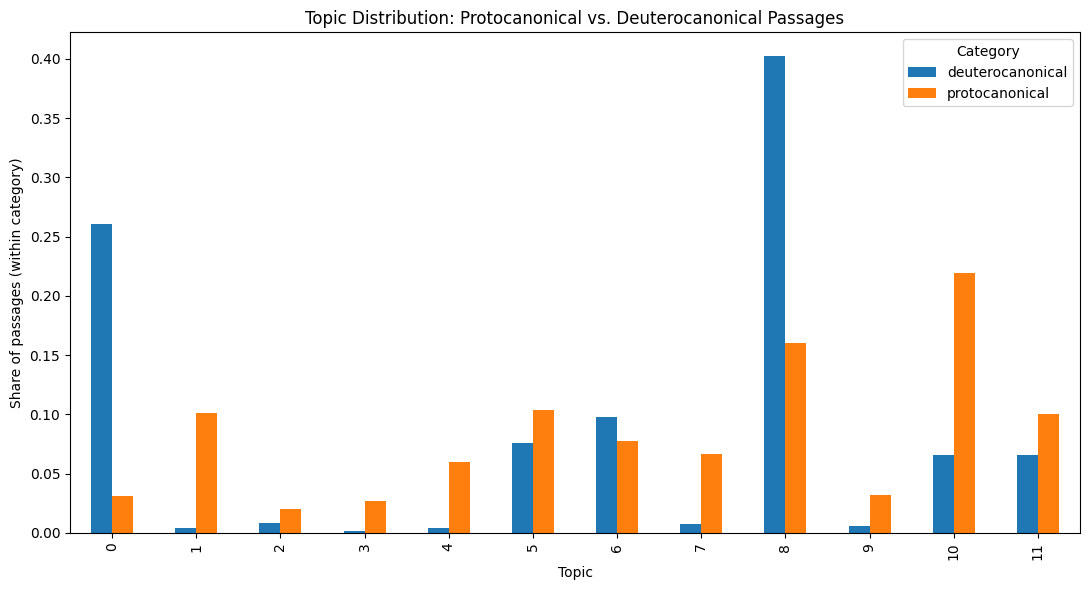

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
topic_by_category.plot(kind='bar', ax=ax)
ax.set_xlabel('Topic')
ax.set_ylabel('Share of passages (within category)')
ax.set_title('Topic Distribution: Protocanonical vs. Deuterocanonical Passages')
ax.legend(title='Category')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_distribution_by_canon_status.png', dpi=150)
plt.show()

## Sanity-check against the `historical_notes.md` case studies

2 Maccabees 12:38–46 (prayer for the dead — deuterocanonical, Catholic/Orthodox-only) and 2 Kings 13:20–21 (Elisha's bones — protocanonical, uncontested) were logged as a contrast pair: both involve God acting through the remains of a deceased holy person, but only one became a canon fault line. This checks whether that theological framing shows up as a *topic* difference between the two books, not just a canon-status difference.

In [8]:
for book in ('2 Maccabees', '2 Kings'):
    counts = passages_df.loc[passages_df['book'] == book, 'dominant_topic'].value_counts()
    print(f'{book}:')
    for topic_idx, count in counts.items():
        print(f'  Topic {topic_idx}: {count} passages - {", ".join(top_words(lda.components_[topic_idx], n=6))}')
    print()

2 Maccabees:
  Topic 0: 71 passages - jews, came, great, men, city, went
  Topic 8: 21 passages - god, hath, things, man, shall, lord
  Topic 5: 5 passages - said, king, lord, hath, god, man
  Topic 6: 4 passages - land, lord, israel, people, egypt, children
  Topic 10: 2 passages - shall, lord, hath, saith, come, earth
  Topic 1: 2 passages - said, shall, jesus, man, saying, come
  Topic 9: 2 passages - david, saul, lord, said, men, went
  Topic 11: 1 passages - thou, thy, thee, shalt, lord, hast

2 Kings:
  Topic 7: 76 passages - king, son, lord, israel, juda, house
  Topic 5: 39 passages - said, king, lord, hath, god, man
  Topic 6: 14 passages - land, lord, israel, people, egypt, children
  Topic 10: 8 passages - shall, lord, hath, saith, come, earth
  Topic 1: 7 passages - said, shall, jesus, man, saying, come
  Topic 11: 5 passages - thou, thy, thee, shalt, lord, hast
  Topic 0: 4 passages - jews, came, great, men, city, went
  Topic 2: 2 passages - gold, silver, house, vessels, 

## Testing the genre-confound hypothesis

`docs/thesis.md` (Section 5.1) flags an open question about the topic-distribution result above: deuterocanonical books happen to be concentrated in genres (Hellenistic historical narrative, wisdom literature) that are comparatively underrepresented among the 39 protocanonical books, so the topic difference could be a genre artifact rather than evidence that deuterocanonical *content* is thematically distinct. This tests that directly by comparing protocanonical and deuterocanonical passages **within the same genre**, rather than as undifferentiated blocks.

Each Old Testament book is assigned one of four standard genre categories (a widely used biblical-studies classification, not something specific to this project): Law (the Pentateuch), Historical Narrative, Wisdom/Poetic, and Prophetic. New Testament books are excluded from this analysis, since no deuterocanonical book has an NT counterpart — the genre-confound question only makes sense within the Old Testament. Law is also excluded: none of the 7 deuterocanonical books fall in it, so there's nothing to compare.

In [9]:
GENRE = {
    'Genesis': 'Law', 'Exodus': 'Law', 'Leviticus': 'Law', 'Numbers': 'Law', 'Deuteronomy': 'Law',
    'Joshua': 'Historical Narrative', 'Judges': 'Historical Narrative', 'Ruth': 'Historical Narrative',
    '1 Samuel': 'Historical Narrative', '2 Samuel': 'Historical Narrative', '1 Kings': 'Historical Narrative',
    '2 Kings': 'Historical Narrative', '1 Chronicles': 'Historical Narrative', '2 Chronicles': 'Historical Narrative',
    'Ezra': 'Historical Narrative', 'Nehemiah': 'Historical Narrative', 'Esther': 'Historical Narrative',
    'Tobit': 'Historical Narrative', 'Judith': 'Historical Narrative', '1 Maccabees': 'Historical Narrative',
    '2 Maccabees': 'Historical Narrative',
    'Job': 'Wisdom/Poetic', 'Psalms': 'Wisdom/Poetic', 'Proverbs': 'Wisdom/Poetic',
    'Ecclesiastes': 'Wisdom/Poetic', 'Song of Solomon': 'Wisdom/Poetic',
    'Wisdom': 'Wisdom/Poetic', 'Sirach': 'Wisdom/Poetic',
    'Isaiah': 'Prophetic', 'Jeremiah': 'Prophetic', 'Lamentations': 'Prophetic', 'Ezekiel': 'Prophetic',
    'Daniel': 'Prophetic', 'Hosea': 'Prophetic', 'Joel': 'Prophetic', 'Amos': 'Prophetic', 'Obadiah': 'Prophetic',
    'Jonah': 'Prophetic', 'Micah': 'Prophetic', 'Nahum': 'Prophetic', 'Habakkuk': 'Prophetic',
    'Zephaniah': 'Prophetic', 'Haggai': 'Prophetic', 'Zechariah': 'Prophetic', 'Malachi': 'Prophetic',
    'Baruch': 'Prophetic',
}

passages_df['genre'] = passages_df['book'].map(GENRE)
ot_df = passages_df.dropna(subset=['genre']).copy()
print(f"{len(ot_df)} OT passages across {ot_df['book'].nunique()} books "
      f"({len(passages_df) - len(ot_df)} NT passages excluded from this analysis)")
ot_df.groupby(['genre', 'category'])['book'].nunique().unstack(fill_value=0)

4754 OT passages across 46 books (1199 NT passages excluded from this analysis)


category,deuterocanonical,protocanonical
genre,,
Historical Narrative,4,12
Law,0,5
Prophetic,1,17
Wisdom/Poetic,2,5


For each genre with passages in both categories, compare the within-genre topic distributions using the Jensen-Shannon distance (symmetric, bounded [0, 1], 0 = identical distributions) against the unconditioned baseline computed above, plus a chi-square test of independence between topic and category restricted to that genre. If genre were the whole story, the within-genre distance should collapse toward 0 and the association should stop being significant.

In [10]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import chi2_contingency

def topic_dist(df):
    counts = df['dominant_topic'].value_counts().reindex(range(N_TOPICS), fill_value=0)
    return counts / counts.sum()

baseline_jsd = jensenshannon(
    topic_dist(ot_df[ot_df.category == 'protocanonical']),
    topic_dist(ot_df[ot_df.category == 'deuterocanonical']),
    base=2,
)
print(f'Baseline (all OT, genre NOT controlled) JSD: {baseline_jsd:.4f}')
print()

genre_results = {}
for genre in ('Historical Narrative', 'Wisdom/Poetic', 'Prophetic'):
    sub = ot_df[ot_df.genre == genre]
    n_proto = (sub.category == 'protocanonical').sum()
    n_deutero = (sub.category == 'deuterocanonical').sum()
    n_deutero_books = sub[sub.category == 'deuterocanonical']['book'].nunique()

    jsd = jensenshannon(
        topic_dist(sub[sub.category == 'protocanonical']),
        topic_dist(sub[sub.category == 'deuterocanonical']),
        base=2,
    )
    ct = pd.crosstab(sub['dominant_topic'], sub['category']).reindex(range(N_TOPICS), fill_value=0)
    ct = ct[ct.sum(axis=1) > 0]
    chi2, p, dof, _ = chi2_contingency(ct)
    genre_results[genre] = {'jsd': jsd, 'p': p, 'n_proto': n_proto, 'n_deutero': n_deutero}

    print(f'{genre} (protocanonical n={n_proto}, deuterocanonical n={n_deutero} from {n_deutero_books} book(s)):')
    print(f'  within-genre JSD: {jsd:.4f}  (baseline was {baseline_jsd:.4f})')
    print(f'  chi2={chi2:.2f}, dof={dof}, p={p:.3g}')
    print()

Baseline (all OT, genre NOT controlled) JSD: 0.5669

Historical Narrative (protocanonical n=1372, deuterocanonical n=374 from 4 book(s)):
  within-genre JSD: 0.6361  (baseline was 0.5669)
  chi2=746.10, dof=11, p=7.02e-153

Wisdom/Poetic (protocanonical n=581, deuterocanonical n=277 from 2 book(s)):
  within-genre JSD: 0.2964  (baseline was 0.5669)
  chi2=79.81, dof=9, p=1.76e-13

Prophetic (protocanonical n=1146, deuterocanonical n=35 from 1 book(s)):
  within-genre JSD: 0.4761  (baseline was 0.5669)
  chi2=84.72, dof=10, p=5.92e-14



### Calibration: how big does a *pure* genre effect look?

To judge whether the within-genre JSDs above are large or small, compare them to the JSD *between* genres among protocanonical passages only — a case with no canon-status difference at all, so any distance here is a pure genre effect.

In [11]:
proto_only = ot_df[ot_df.category == 'protocanonical']
genres = ['Law', 'Historical Narrative', 'Wisdom/Poetic', 'Prophetic']

print('Protocanonical-only, cross-genre JSD (pure genre effect, for calibration):')
for i in range(len(genres)):
    for j in range(i + 1, len(genres)):
        d = jensenshannon(
            topic_dist(proto_only[proto_only.genre == genres[i]]),
            topic_dist(proto_only[proto_only.genre == genres[j]]),
            base=2,
        )
        print(f'  {genres[i]} vs {genres[j]}: JSD={d:.4f}')

Protocanonical-only, cross-genre JSD (pure genre effect, for calibration):
  Law vs Historical Narrative: JSD=0.4694
  Law vs Wisdom/Poetic: JSD=0.6712
  Law vs Prophetic: JSD=0.4928
  Historical Narrative vs Wisdom/Poetic: JSD=0.8062
  Historical Narrative vs Prophetic: JSD=0.6908
  Wisdom/Poetic vs Prophetic: JSD=0.5707


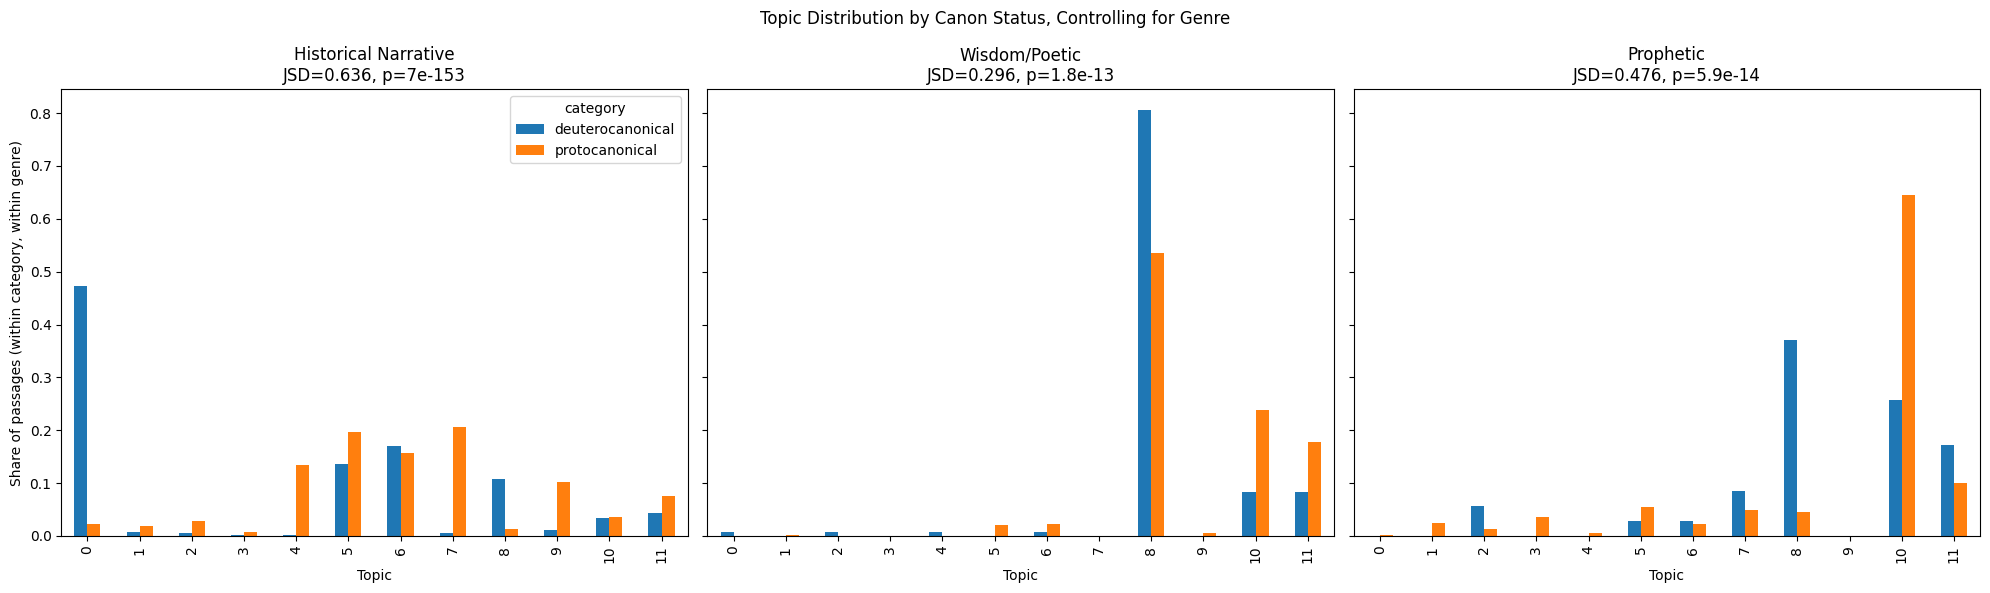

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, genre in zip(axes, ('Historical Narrative', 'Wisdom/Poetic', 'Prophetic')):
    sub = ot_df[ot_df.genre == genre]
    dist = pd.crosstab(sub['dominant_topic'], sub['category'], normalize='columns')
    dist = dist.reindex(range(N_TOPICS), fill_value=0)
    dist.plot(kind='bar', ax=ax, legend=(genre == 'Historical Narrative'))
    r = genre_results[genre]
    ax.set_title(f"{genre}\nJSD={r['jsd']:.3f}, p={r['p']:.2g}")
    ax.set_xlabel('Topic')

axes[0].set_ylabel('Share of passages (within category, within genre)')
fig.suptitle('Topic Distribution by Canon Status, Controlling for Genre')
plt.tight_layout()
plt.savefig('../outputs/figures/topic_distribution_by_genre.png', dpi=150)
plt.show()

### Interpretation

The genre-confound hypothesis is only **partially** supported, and not in the direction that would undercut the main result:

- **Historical Narrative** (Tobit, Judith, 1-2 Maccabees vs. Joshua-Esther) — the genre holding 4 of the 7 deuterocanonical books and most of the deuterocanonical passage count — shows a within-genre JSD *larger* than the unconditioned baseline, not smaller, with an overwhelmingly significant chi-square association (p far below any conventional threshold). Controlling for genre does not explain this difference away; if anything it sharpens it. Deuterocanonical historical narrative concentrates heavily in one topic (Jerusalem/political-actor narrative) that protocanonical historical narrative spreads more evenly across several royal/dynastic and court-narrative topics.
- **Wisdom/Poetic** (Wisdom, Sirach vs. Job-Song of Solomon) is where the confound hypothesis holds up best: the within-genre gap is roughly half the unconditioned baseline. Both groups concentrate in the same dominant topic (general moral/wisdom exhortation), but the deuterocanonical pair concentrates in it more heavily — a difference of degree, not of which topic dominates. The association remains statistically significant, but the genre explains a real share of the original effect here.
- **Prophetic** (Baruch alone vs. Isaiah-Malachi) falls between the two, but rests on a single deuterocanonical book and 35 passages — too small a sample to draw a confident conclusion either way.
- **Calibration:** cross-genre JSDs among protocanonical passages alone (no canon-status difference present) range from about 0.47 to 0.81. The within-genre canon-status JSDs above (0.30-0.64) are the same order of magnitude as genre-driven differences themselves — canon status is not a negligible signal relative to genre, even where genre does explain part of it.

**Bottom line:** the original topic-distribution finding survives this more rigorous test. It is not simply an artifact of deuterocanonical books happening to be historical narrative and wisdom literature - the Historical Narrative subset, which carries most of the deuterocanonical corpus, shows *more* topic separation once genre is controlled for, not less. The effect is driven more by the historical-narrative books than by the wisdom literature, which is a real nuance the unconditioned result in the previous section couldn't show on its own.

**Read this alongside the printed topic word lists above** — look at which topic(s) dominate each book and whether the words fit the historical_notes.md framing (e.g. a narrative/historical topic vs. a law-and-worship or wisdom topic). This notebook doesn't hardcode an interpretation here since it depends on the actual topic words produced by your run, which can shift with `N_TOPICS` or `random_state`.

## Next steps

- Tune `N_TOPICS` (try 8–20) and check topic stability — LDA topics can be sensitive to this.
- Compare against a BERTopic run once/if that dependency gets installed (see the intro cell) — embedding-based topics may separate deuterocanonical wisdom literature (Wisdom, Sirach) from deuterocanonical narrative (Tobit, Judith, Maccabees) better than bag-of-words LDA does here.
- Consider repeating this analysis on the Orthodox corpus's *additional* four books (1 Esdras, 3 Maccabees, Prayer of Manasseh, Psalm 151) vs. the Catholic 46 — note that would mix Septuagint/KJV text with Douay-Rheims text, so translation-artifact risk is higher there (see `align_corpus.CANONICAL_SOURCES`).
- The genre-confound test above still leaves the Prophetic result (Baruch alone, 35 passages) underpowered - would need a second deuterocanonical prophetic-genre book to say anything confident there, and none exists in this canon list.